# Построение карты фрактальной размерности

In [1]:
from pathlib import Path
import rasterio as rs
import numpy as np
import torch
from utils.fractal_map import fractal_dimension_map_2d

lineaments_dir_path = Path(r"D:\ml_datasets\Chukotka\фильтрация по длине линеаментов 1000m")
lineaments = {}
for f in lineaments_dir_path.iterdir():
    lenght = int(f.stem.split("_")[-2].replace("ml", ""))
    lineaments[lenght] = f

tensor = torch.tensor(rs.open(lineaments[20]).read(1)) 
result = fractal_dimension_map_2d(tensor.float(), threshold= np.percentile(tensor, 50), window_size=81, 
                                  eps_list=(3, 9, 27, 81))

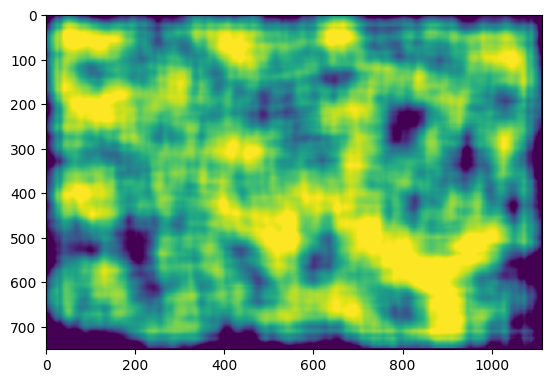

In [2]:
import matplotlib.pyplot as plt 

plt.imshow(result, vmin=np.percentile(result, 5), vmax = np.percentile(result, 95))

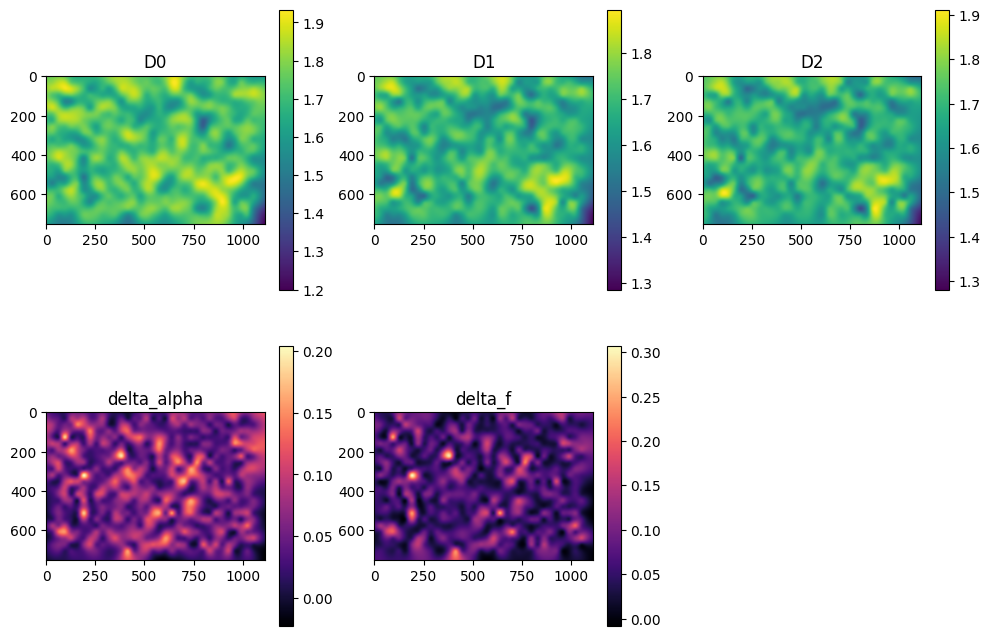

In [3]:
from utils.multifractal import compute_spatial_multifractal_maps


import matplotlib.pyplot as plt
np.random.seed(0)
H, W = 400, 400
data = np.random.rand(H, W)  # здесь — твоя карта концентраций (>=0)
# create a synthetic anomaly area
data[150:260, 180:260] += 3.0

# параметры (подбери в соответствии с разрешением данных)
window_size = 64         # размер ячейки (km-пересчет если нужно)
stride = 32              # перекрывающиеся окна
# r_list: боксы для мультифрактала (в пикселях), должны быть <= window_size
r_list = [1, 2, 4, 8, 16]    # минимум ~5 масштабов рекомендуется
q_list = np.array([0.0, 1.0, 2.0, 3.0])  # минимум q=0,1,2; можно расширить

maps = compute_spatial_multifractal_maps(tensor, window_size, r_list, q_list, stride=stride, mode='sliding')

plt.figure(figsize=(12, 8))
plt.subplot(231); plt.title('D0'); plt.imshow(maps['D0'], cmap='viridis'); plt.colorbar()
plt.subplot(232); plt.title('D1'); plt.imshow(maps['D1'], cmap='viridis'); plt.colorbar()
plt.subplot(233); plt.title('D2'); plt.imshow(maps['D2'], cmap='viridis'); plt.colorbar()
plt.subplot(234); plt.title('delta_alpha'); plt.imshow(maps['delta_alpha'], cmap='magma'); plt.colorbar()
plt.subplot(235); plt.title('delta_f'); plt.imshow(maps['delta_f'], cmap='magma'); plt.colorbar()
plt.show()

In [8]:
meta = rs.open(lineaments[20]).meta

name = "delta_f"
with rs.open(f"{name}.tif", "w", **meta) as dst:
    dst.write(maps[name], 1)

# Выделение статистики

(array([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 0., 0., 2., 0., 0., 0., 0., 0., 0., 1., 1.,
        1., 0., 1., 1., 1., 0., 0., 1., 4., 0., 1., 4., 4., 3., 3., 2., 0.,
        4., 4., 3., 2., 2., 2., 3., 1., 0., 2., 1., 3., 2., 2., 5., 6., 0.,
        0., 2., 3., 6., 3., 2., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0.,
        1., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.]),
 array([1.44394696, 1.44872797, 1.45350885, 1.45828986, 1.46307087,
        1.46785176, 1.47263277, 1.47741377, 1.48219466, 1.48697567,
        1.49175668, 1.49653757, 1.50131857, 1.50609946, 1.51088047,
        1.51566148, 1.52044237, 1.52522337, 1.53000438, 1.53478527,
        1.53956628, 1.54434729, 1.54912817, 1.55390918, 1.55869019,
        1.56347108, 1.56825209, 1.57303309, 1.57781398, 1.58259499,
        1.58737588, 1.59215689, 1.59693789, 1.60171878, 1.60649979,
        1.6112808 , 1.61606169, 1.6208427 , 1.6256237 , 1.63040459,
      

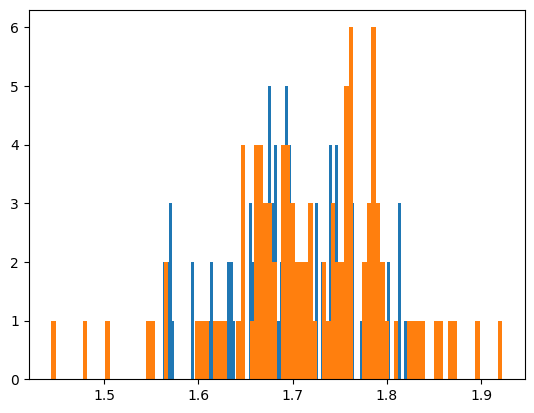

In [ ]:
from utils.points_from_raster import extract_raster_values_at_points
import matplotlib.pyplot as plt
import rasterio as rs

fractal_dimention_path = r"C:\Users\Admin\Desktop\pythonProjects\MPM\fractal_analysis\D0.tif"

coords, values = extract_raster_values_at_points(
    raster_path=fractal_dimention_path,
    shp_path=r"D:\ml_datasets\Chukotka\mineral_points\04_07_02_Occurrences"
)

random_values = rs.open(fractal_dimention_path).read().flatten()[::8000]

plt.hist(values, bins = 100)
plt.hist(random_values, bins=100)

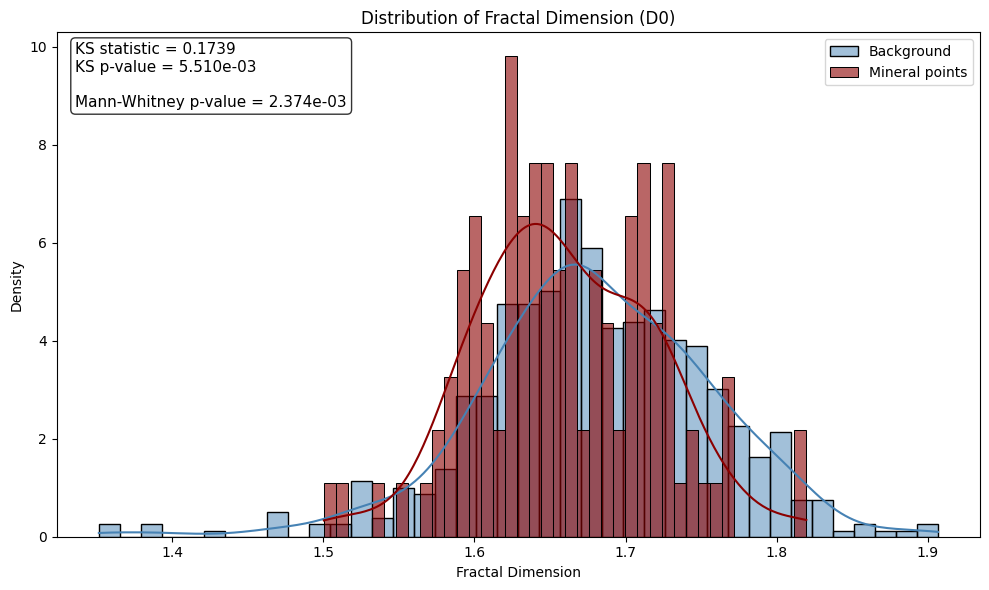


=== Statistical Tests ===
KS test p-value: 5.510e-03
Mann-Whitney p-value: 2.374e-03
KS: Distributions are significantly different.
Mann-Whitney: Medians significantly different.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from scipy import stats
import seaborn as sns

# ---------------------------
# 1. Загрузка данных
# ---------------------------
fractal_dimension_path = r"C:\Users\Admin\Desktop\pythonProjects\MPM\fractal_analysis\D2.tif"

coords, values = extract_raster_values_at_points(
    raster_path=fractal_dimension_path,
    shp_path=r"D:\ml_datasets\Chukotka\mineral_points\04_07_02_Occurrences"
)

with rasterio.open(fractal_dimension_path) as src:
    raster = src.read(1)
    nodata = src.nodata

# Убираем nodata
if nodata is not None:
    raster = raster[raster != nodata]

# Берём случайную подвыборку фона
np.random.seed(42)
background = np.random.choice(raster.flatten(), size=min(len(values)*5, 50000), replace=False)

# ---------------------------
# 2. Статистические тесты
# ---------------------------

# Kolmogorov-Smirnov
ks_stat, ks_p = stats.ks_2samp(values, background)

# Mann-Whitney U (лучше для геоданных)
mw_stat, mw_p = stats.mannwhitneyu(values, background, alternative='two-sided')

# ---------------------------
# 3. Визуализация
# ---------------------------

plt.figure(figsize=(10,6))

sns.histplot(background, bins=40, stat="density", 
             color="steelblue", alpha=0.5, label="Background", kde=True)

sns.histplot(values, bins=40, stat="density", 
             color="darkred", alpha=0.6, label="Mineral points", kde=True)

plt.title("Distribution of Fractal Dimension (D0)")
plt.xlabel("Fractal Dimension")
plt.ylabel("Density")
plt.legend()

# Подпись со статистикой
textstr = (
    f"KS statistic = {ks_stat:.4f}\n"
    f"KS p-value = {ks_p:.3e}\n\n"
    f"Mann-Whitney p-value = {mw_p:.3e}"
)

plt.gca().text(0.02, 0.98, textstr,
               transform=plt.gca().transAxes,
               fontsize=11,
               verticalalignment='top',
               bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# ---------------------------
# 4. Интерпретация
# ---------------------------

print("\n=== Statistical Tests ===")
print(f"KS test p-value: {ks_p:.3e}")
print(f"Mann-Whitney p-value: {mw_p:.3e}")

if ks_p < 0.05:
    print("KS: Distributions are significantly different.")
else:
    print("KS: No significant difference detected.")

if mw_p < 0.05:
    print("Mann-Whitney: Medians significantly different.")
else:
    print("Mann-Whitney: No significant median difference.")